# What the fitted models can and cannot tell you about funding

Notebooks 06 through 11 each fitted a family and published its validation predictions. This one
reads all of them together and asks what they say - and, as importantly, what they are not
entitled to say.

**Three metrics appear here and none of them selects anything.**

The **information coefficient** is the rank correlation, on each settlement, between the
predictions and the returns that followed, averaged over settlements. It asks whether the model
ordered the perpetuals correctly. It is silent on how far apart they were: a model that ranks
perfectly and separates the top from the bottom by a basis point scores the same as one that
separates them by a percent.

**AUC** applies to the two direction labels rather than to returns. It is the probability that a
randomly chosen settlement the model scored higher went on to rise, against one it scored lower.
Half is a coin. It measures ordering too, so it is silent about calibration - a model whose
probabilities are all near one half in the right order scores well.

**Log loss** is the one that reads the probabilities as probabilities. It punishes confidence in
the wrong direction far more than hesitation, so a model can improve its AUC and worsen its log
loss at the same time by ordering better while becoming overconfident.

**Why none of them chooses the strategy.** Every one measures the signal in isolation, on the
settlements where it happened to be scored, before any position is sized, any perpetual is
funded, or any cost is paid. A model with the highest IC can lose to a lower-ranked one after
funding and turnover, and on this case study it can lose for a reason specific to perpetuals:
funding is paid by whoever holds the position at settlement, so a signal that flips often pays
it repeatedly. Selection therefore happens in [`13_backtest`](13_backtest.ipynb) and after, on
validation backtest Sharpe. The numbers here are for understanding what was fitted.

**Every checkpoint stays a row.** The deep-learning families save weights every 25 epochs, so a
configuration arrives here as eight scoreable models rather than one. They are not collapsed to
a per-configuration best: taking the best epoch of each family and comparing those is choosing
after seeing the answer, and the epoch that wins on validation is not the one a reader could
have picked in advance.

**Learning objectives.** By the end of this notebook you will be able to:

- Say what IC, AUC and log loss each measure, and name a model that would score well on one
  while scoring badly on another.
- Explain why a ranking metric cannot decide a trading configuration, and what specifically
  about perpetual funding widens that gap.
- Read a distribution that keeps every checkpoint, and say why collapsing it to a per-family
  best would flatter whichever family saves the most.
- Say why the causal estimate is reported beside these tables rather than among them.

**Book reference:** Chapters 11 to 19, model comparison and diagnostics.

**Prerequisites:** complete canonical outputs from [`06_linear`](06_linear.ipynb) through
[`10_dl_tcn`](10_dl_tcn.ipynb), and the causal result from
[`11_causal_dml`](11_causal_dml.ipynb).

**What it writes:** nothing to the registry. This notebook is read-only over what the model
notebooks published; every table below is a description of rows that already exist, and no
decision taken here propagates anywhere.

In [1]:
import os

import plotly.express as px
import polars as pl
from IPython.display import Markdown

from case_studies.crypto_perps_funding.research_workflow import (
    OFFICIAL_POPULATION,
    open_study,
    plan_official_models,
)
from case_studies.research import CausalResult, OfficialPopulation, superseded_members
from utils.style import COLORS, ml4t_palette, show_plotly_with_alt

In [2]:
EXECUTION_TIER = "canonical"
WORKSPACE = os.environ.get("ML4T_OUTPUT_DIR", "")

## 1. Assemble the complete predictive catalog

Diagnostics on a partial catalog are worse than no diagnostics, because they look the same. If
one family's checkpoints are missing, every cross-family comparison below silently becomes a
comparison over a different set of models, and nothing in the resulting tables says so. So the
catalog is assembled and checked for completeness first, and the analysis refuses to begin
otherwise.

In [3]:
study = open_study(execution_tier=EXECUTION_TIER, workspace=WORKSPACE or None)
catalog = study.predictions.table(include_preview=EXECUTION_TIER == "preview").filter(
    (pl.col("identity_status") == "current")
    & (pl.col("execution_tier") == EXECUTION_TIER)
    & (pl.col("split") == "validation")
    & pl.col("complete")
)
# `identity_status` names the schema version a row was written under, not the generation its
# producer still publishes. A model notebook that refits leaves the generation it replaced in
# the registry - complete, and current under a column that has not moved - so the filter above
# carries retired prediction sets into the analysis. The population lineage is what answers it,
# and `superseded_members` reads that, so the analysed catalog and the frozen population
# describe one set of models rather than two.
retired = superseded_members(study, member_kind="prediction")
if retired:
    catalog = catalog.filter(~pl.col("prediction_hash").is_in(list(retired)))

if catalog.is_empty() or catalog["prediction_hash"].n_unique() != catalog.height:
    raise RuntimeError("the canonical model catalog is empty or has duplicate identities")

Canonical analysis also reconstructs the complete request population. Exact hash equality makes a
missing, extra, or differently resolved checkpoint a blocking error before diagnostics begin.

In [4]:
if EXECUTION_TIER == "canonical":
    population = OfficialPopulation.one(study, name=OFFICIAL_POPULATION)
    population.require_complete()
    declared_hashes = set(plan_official_models(study).expected_prediction_hashes)
    frozen_hashes = set(population.members)
    if frozen_hashes != declared_hashes:
        raise RuntimeError("the frozen model population differs from the declared requests")
    if set(catalog["prediction_hash"]) != frozen_hashes:
        raise RuntimeError("the canonical model catalog differs from the declared population")

In [5]:
catalog.select(
    "family",
    "label",
    "config_name",
    "checkpoint_kind",
    "checkpoint_value",
    "training_hash",
    "prediction_hash",
    "ic_mean",
    "auc_roc",
    "log_loss",
).sort("label", "family", "config_name", "checkpoint_value")

family,label,config_name,checkpoint_kind,checkpoint_value,training_hash,prediction_hash,ic_mean,auc_roc,log_loss
str,str,str,str,i64,str,str,f64,f64,f64
"""gbm""","""fwd_dir_8h""","""default_binary""","""iteration""",50,"""fd68607ee6b1""","""01ba8d21dca9""",0.009315,0.509794,0.709765
"""gbm""","""fwd_dir_8h""","""default_binary""","""iteration""",100,"""fd68607ee6b1""","""a91aaaa7f96b""",0.01547,0.510269,0.717976
"""gbm""","""fwd_dir_8h""","""default_binary""","""iteration""",150,"""fd68607ee6b1""","""8f3fa855cabb""",0.020482,0.510288,0.727208
"""gbm""","""fwd_dir_8h""","""default_binary""","""iteration""",200,"""fd68607ee6b1""","""bb582291a3f4""",0.016677,0.50788,0.734114
"""gbm""","""fwd_dir_8h""","""default_binary""","""iteration""",250,"""fd68607ee6b1""","""f2552e8b9b88""",0.010323,0.507225,0.7397
…,…,…,…,…,…,…,…,…,…
"""tabular_dl""","""fwd_ret_8h""","""tabm_s""","""epoch""",100,"""4ba969184c07""","""1e4b587ae3f7""",0.011571,null,null
"""tabular_dl""","""fwd_ret_8h""","""tabm_s""","""epoch""",125,"""4ba969184c07""","""3700b2926606""",0.007887,null,null
"""tabular_dl""","""fwd_ret_8h""","""tabm_s""","""epoch""",150,"""4ba969184c07""","""90a47d7dbfd6""",0.008811,null,null


## 2. Diagnostic summaries

These tables describe the registered validation predictions without collapsing checkpoint
identity or intersecting away missing keys. Any incomplete row was rejected before this analysis.

Both of those conditions are doing work. **Not collapsing checkpoints** means a deep-learning
configuration appears as its eight scored models rather than as one number chosen after the fact;
what you are reading is a distribution per family, not a leaderboard. **Not intersecting keys**
means each row is scored on the settlements its own fold declares, rather than on the settlements
every family happens to share. Intersecting would make the numbers look more comparable while
quietly changing the sample each was measured on - and on an unbalanced perpetual panel, where
symbols list and delist mid-history, that intersection can be a good deal smaller than any
individual family's coverage.

Read these as descriptions of what was fitted. A family that scores poorly here may still win the
backtest, and a family that scores well here may lose it to funding paid on a signal that flips.

In [6]:
diagnostics = catalog.select(
    "label",
    "family",
    "config_name",
    "checkpoint_kind",
    "checkpoint_value",
    "training_hash",
    "prediction_hash",
    "n_folds",
    "ic_mean",
    "ic_std",
    "auc_roc",
    "log_loss",
).sort("label", "family", "config_name", "checkpoint_value")
diagnostics

label,family,config_name,checkpoint_kind,checkpoint_value,training_hash,prediction_hash,n_folds,ic_mean,ic_std,auc_roc,log_loss
str,str,str,str,i64,str,str,f64,f64,f64,f64,f64
"""fwd_dir_8h""","""gbm""","""default_binary""","""iteration""",50,"""fd68607ee6b1""","""01ba8d21dca9""",2.0,0.009315,0.010972,0.509794,0.709765
"""fwd_dir_8h""","""gbm""","""default_binary""","""iteration""",100,"""fd68607ee6b1""","""a91aaaa7f96b""",2.0,0.01547,0.013814,0.510269,0.717976
"""fwd_dir_8h""","""gbm""","""default_binary""","""iteration""",150,"""fd68607ee6b1""","""8f3fa855cabb""",2.0,0.020482,0.00742,0.510288,0.727208
"""fwd_dir_8h""","""gbm""","""default_binary""","""iteration""",200,"""fd68607ee6b1""","""bb582291a3f4""",2.0,0.016677,0.008544,0.50788,0.734114
"""fwd_dir_8h""","""gbm""","""default_binary""","""iteration""",250,"""fd68607ee6b1""","""f2552e8b9b88""",2.0,0.010323,0.007288,0.507225,0.7397
…,…,…,…,…,…,…,…,…,…,…,…
"""fwd_ret_8h""","""tabular_dl""","""tabm_s""","""epoch""",100,"""4ba969184c07""","""1e4b587ae3f7""",2.0,0.011571,0.015978,null,null
"""fwd_ret_8h""","""tabular_dl""","""tabm_s""","""epoch""",125,"""4ba969184c07""","""3700b2926606""",2.0,0.007887,0.015736,null,null
"""fwd_ret_8h""","""tabular_dl""","""tabm_s""","""epoch""",150,"""4ba969184c07""","""90a47d7dbfd6""",2.0,0.008811,0.015615,null,null


The distribution below retains every checkpoint. A family with more configured checkpoints is
therefore shown with more points rather than receiving extra weight in a collapsed ranking.

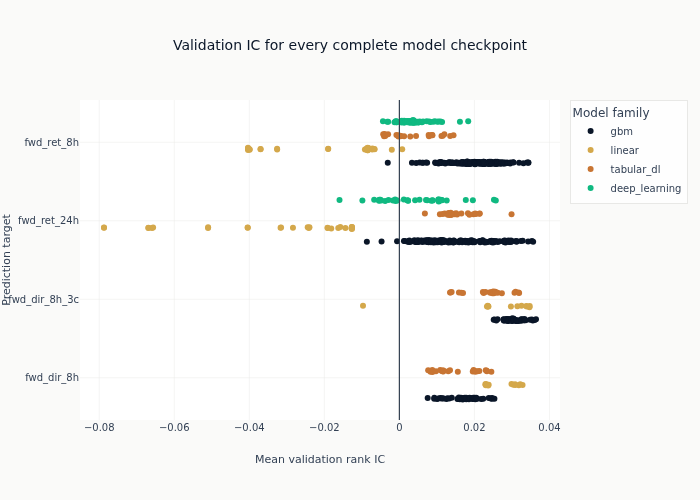

In [7]:
ic_points = catalog.filter(pl.col("ic_mean").is_not_null()).sort(
    "label", "family", "config_name", "checkpoint_value"
)
fig = px.strip(
    ic_points,
    x="ic_mean",
    y="label",
    color="family",
    hover_data=["config_name", "checkpoint_kind", "checkpoint_value"],
    title="Validation IC for every complete model checkpoint",
    labels={"ic_mean": "Mean validation rank IC", "label": "Prediction target"},
    color_discrete_sequence=ml4t_palette(5, categorical=True),
)
fig.add_vline(x=0, line_width=1, line_color=COLORS["neutral"])
fig.update_layout(legend_title_text="Model family")
show_plotly_with_alt(
    fig,
    "Horizontal strip plot with one point per complete model checkpoint, grouped by prediction "
    "target and colored by model family. A vertical zero line separates positive and negative "
    "validation rank correlations.",
)

## The causal estimate, reported beside the diagnostics and not among them

The double machine learning estimate from [`11_causal_dml`](11_causal_dml.ipynb) answers a
different question from every metric above. Those ask how well a model orders perpetuals it did
not train on. This asks what would happen to the return if the treatment were changed, holding
the confounders fixed - a claim about an intervention, not about a ranking.

The two do not convert into one another in either direction. A model with a high IC has found
something that predicts, which may be an effect, a proxy for one, or a regularity with no causal
content at all. An effect estimate that is large and well identified need not predict well,
because most of the variation in funding is not the treatment. Putting them in one table would
invite exactly that arithmetic, so the estimate is reported on its own with its own uncertainty.

`refutation_p` is the placebo check rather than a significance test: it asks how often an
estimate this large appears once the treatment is disrupted. It is nullable by contract, and a
run that did not reach a verdict is reported as not having one.

In [8]:
causal = CausalResult.one(study, label="fwd_ret_8h", execution_tier=EXECUTION_TIER)
if not causal.complete:
    raise RuntimeError("causal result is incomplete")
causal_summary = pl.DataFrame(
    {
        "causal_hash": [causal.hash],
        "n_obs": [causal.metrics["n_obs"]],
        "effect": [causal.metrics["dml_effect"]],
        "hac_standard_error": [causal.metrics["dml_se_hac"]],
        "refutation_p": [causal.metrics["refutation_p"]],
    }
)
causal_summary

causal_hash,n_obs,effect,hac_standard_error,refutation_p
str,i64,f64,f64,f64
"""6d6ef40064b1""",54314,0.001032,0.000971,0.386139


In [9]:
# refutation_p is nullable by contract (`case_studies/utils/causal.py`), so it is reported as absent
# rather than formatted. A run whose refutation did not produce an empirical p-value is a
# weaker result, and saying so is more useful than omitting the sentence or failing to render.
#
# `refutation_n_successful` is the denominator the p-value was actually computed over, and it
# is not the requested count: `empirical_permutation_p` drops placebos whose second stage
# returned NaN. It arrived with a migration, so a row written before the column existed
# carries None, and `CausalResult.open` then publishes no `refutation_class` at all rather
# than classifying on the p-value alone. This run is one of those rows.
_refutation = causal.metrics["refutation_p"]
_n_successful = causal.metrics["refutation_n_successful"]
_refutation_class = causal.metrics["refutation_class"]
_n_placebo = causal.spec["computation"]["refutation"]["n_placebo"]
_floor = 1.0 / (_n_placebo + 1)
if _refutation is None:
    _refutation_text = "No temporal refutation p-value was registered for this estimate."
elif _refutation <= _floor:
    # The floor pins the denominator even when the column is absent. The p-value is
    # (1 + exceedances) / (1 + successful) with at least one in the numerator, and
    # successful <= requested, so p <= 1/(requested + 1) is only reachable when every
    # requested placebo succeeded and none was as extreme as the observed effect. So this
    # branch may state the count and the exceedances without reading either back.
    #
    # What the floor does NOT establish is that the underlying permutation tail probability
    # is at most 1/(n+1). That is a property of all permutations; this is a sample of n of
    # them, and zero exceedances in a sample bounds the sample, not the population.
    _refutation_text = (
        f"The temporal refutation p-value is **{_refutation:.3f}**, the smallest value "
        f"{_n_placebo} permutations can produce: every placebo fit succeeded and none was "
        f"as extreme as the observed effect. This is the Monte Carlo estimate sitting at "
        f"its resolution floor of 1/{_n_placebo + 1}, not a bound on the permutation tail "
        f"probability itself - resolving that finer needs more permutations, not a smaller "
        f"reported number."
    )
    # Being at the floor is not the same as being able to reject from there. Below 20
    # draws the floor itself sits above 5 %, so the run is simultaneously as extreme as
    # its permutation count allows and unable to reject at all - the verdict has to be
    # said out loud rather than left to the reassuring half of the sentence.
    if _refutation_class == "Underpowered":
        _refutation_text += (
            f" Even so, the registered verdict is **Underpowered**: with {_n_placebo} "
            "permutations the floor is above 5 %, so no outcome of this test could have "
            "rejected."
        )
elif _n_successful is None:
    # Off the floor the denominator matters and is not recoverable, so the count is not
    # asserted and no pass/fail verdict is published - the registry withholds one for
    # exactly this reason.
    _refutation_text = (
        f"The temporal refutation p-value is **{_refutation:.3f}**, a Monte Carlo estimate "
        f"over at most the {_n_placebo} requested permutations. How many of them actually "
        "produced a second-stage fit is not registered for this run, so the effective "
        "sample behind the estimate - and with it whether the draws could have rejected at "
        "all - cannot be read back, and no pass/fail verdict is published."
    )
else:
    _refutation_text = (
        f"The temporal refutation p-value is **{_refutation:.3f}**, a Monte Carlo estimate "
        f"over the **{_n_successful}** of {_n_placebo} requested permutations whose second "
        f"stage produced a fit, and no finer than that sample supports. The registered "
        f"verdict is **{_refutation_class}**"
        + (
            " - too few successful draws to reject at 5 % whatever the data showed. "
            if _refutation_class == "Underpowered"
            else ". "
        )
    )

_effect = causal.metrics["dml_effect"]
_se = causal.metrics["dml_se_hac"]
_t = _effect / _se if _se else float("nan")
# The block and the bandwidth are sized by different rules and the reader is being asked to
# weigh a ratio built from the second. The bandwidth is not statsmodels': it requires an
# explicit `maxlags` for both `HAC` and `hac-groupsum` and supplies no default. The
# cube-root-of-decision-times rule is this repository's own fallback, applied in
# `manual_dml_timeseries` in `case_studies/utils/causal.py` because no `hac_maxlags` is
# passed, and then raised to `horizon - 1` (`run_dml_analysis` only warns and forwards).
# The realized bandwidth is not registered - `causal_runs` stores neither `hac_maxlags` nor
# `n_periods` - so the notebook states the rule rather than a number it cannot read back.
#
# The two window quantities decide the wording, not `block_size_basis`. The basis string
# cannot carry it: `block_size = max(horizon_steps, treatment_window_steps or 1)` and the
# basis is resolved by equality, so `label_horizon` covers both an undeclared window and a
# declared one shorter than the horizon, while `treatment_window` includes the case where the
# two are equal and the bandwidth already covers the block to within a lag. Only
# `treatment_window_steps > label_horizon_steps` is the situation the caveat describes.
_refutation_spec = causal.spec["computation"]["refutation"]
_block = _refutation_spec["block_size"]
_window_steps = _refutation_spec["treatment_window_steps"]
_horizon_steps = _refutation_spec["label_horizon_steps"]
_n_timestamps = causal.spec["computation"]["analysis_population"]["n_timestamps"]
if _window_steps is not None and _window_steps > _horizon_steps:
    _bandwidth_text = (
        f"One caveat on the ratio: the placebo block spans **{_block}** bars of treatment "
        "persistence, and the standard error behind this ratio is not sized by the same "
        "quantity. Its HAC bandwidth is `max(label horizon - 1, cube root of the "
        f"decision-time count)`, whose horizon term is {_horizon_steps - 1} on this run. "
        "Neither term refers to the treatment, so whether the bandwidth happens to reach "
        "across the block is incidental, and its realized value is not registered. "
        "`causal_runs` stores no `hac_maxlags`, and the count the cube root is taken over is "
        "not the one in the spec: the bandwidth counts decision times that survive "
        "cross-fitting, while the registered "
        f"`analysis_population.n_timestamps` of {_n_timestamps} counts the whole analysis "
        "frame, including the first walk-forward block, which yields no out-of-fold "
        "residuals. Nor does "
        "the mismatch settle which way the standard error would move under a bandwidth that "
        "did span the block: a HAC estimate is not monotonic in its bandwidth, because the "
        "autocovariances a longer one admits can carry either sign, and the treatment's "
        "construction window is an argument for the block rather than a derivation of the "
        "right bandwidth. Read the ratio as provisional until the estimate is recomputed "
        "across a range of defensible bandwidths. "
    )
else:
    _bandwidth_text = (
        f"The placebo block spans **{_block}** bars, sized by the label horizon, which is at "
        "least as long as any construction window declared for the treatment"
        + (" - none is declared here. " if _window_steps is None else f" ({_window_steps}). ")
        + "So the block does not exceed the label horizon, and the standard error's "
        "bandwidth covers it to within a lag rather than falling short of it. "
    )
Markdown(
    f"The registered DML estimate is **{_effect:+.4g}** with "
    f"a HAC standard error of **{_se:.4g}**, a ratio of **{_t:.2f}**. {_refutation_text} "
    "Read the two together: the placebo test asks whether the estimation procedure "
    "manufactures this effect out of permuted treatment, and the standard error asks "
    "whether the effect is separable from zero at all. Surviving the first while failing "
    "the second is not evidence of a causal effect. "
    f"{_bandwidth_text}"
    "This result describes the declared causal estimand and does not rank predictive models "
    "or trading strategies."
)

The registered DML estimate is **+0.001032** with a HAC standard error of **0.0009709**, a ratio of **1.06**. The temporal refutation p-value is **0.386**, a Monte Carlo estimate over the **100** of 100 requested permutations whose second stage produced a fit, and no finer than that sample supports. The registered verdict is **Fails**.  Read the two together: the placebo test asks whether the estimation procedure manufactures this effect out of permuted treatment, and the standard error asks whether the effect is separable from zero at all. Surviving the first while failing the second is not evidence of a causal effect. One caveat on the ratio: the placebo block spans **42** bars of treatment persistence, and the standard error behind this ratio is not sized by the same quantity. Its HAC bandwidth is `max(label horizon - 1, cube root of the decision-time count)`, whose horizon term is 0 on this run. Neither term refers to the treatment, so whether the bandwidth happens to reach across the block is incidental, and its realized value is not registered. `causal_runs` stores no `hac_maxlags`, and the count the cube root is taken over is not the one in the spec: the bandwidth counts decision times that survive cross-fitting, while the registered `analysis_population.n_timestamps` of 4120 counts the whole analysis frame, including the first walk-forward block, which yields no out-of-fold residuals. Nor does the mismatch settle which way the standard error would move under a bandwidth that did span the block: a HAC estimate is not monotonic in its bandwidth, because the autocovariances a longer one admits can carry either sign, and the treatment's construction window is an argument for the block rather than a derivation of the right bandwidth. Read the ratio as provisional until the estimate is recomputed across a range of defensible bandwidths. This result describes the declared causal estimand and does not rank predictive models or trading strategies.

## Key takeaways and limitations

- **Completeness is checked before anything is interpreted.** A diagnostic computed over a
  catalog missing a family's checkpoints reads exactly like one computed over a complete catalog.
  That is why the check is a blocking error rather than a warning.
- **These three metrics describe predictions; none of them selects.** IC and AUC measure ordering
  and are silent about magnitude and calibration respectively; log loss reads probabilities as
  probabilities and can move opposite to AUC. Selection is validation backtest Sharpe, in
  [`13_backtest`](13_backtest.ipynb).
- **On perpetuals the gap between ranking and Sharpe has a specific cause.** Funding is paid by
  whoever holds the position at settlement, so a signal that reverses often pays it repeatedly. A
  ranking metric cannot see that, because it never holds anything.
- **Every checkpoint stays a row, so more checkpoints means more points and not more weight.**
  Collapsing to a per-configuration best would flatter whichever family saves most often, and
  would report a maximum over draws as if it were one model's score.
- **The causal estimate sits beside these tables and does not convert into them.** A high IC may
  be an effect, a proxy for one, or a regularity with no causal content; a well-identified effect
  need not predict, because most of the variation in funding is not the treatment. Putting both
  in one table would invite arithmetic that neither supports.
- **Everything here is conditional on the finalized features, labels, universe and validation
  period**, and the causal estimate is additionally conditional on its declared
  observed-confounder assumptions. Two validation folds is what this case study's history
  supports, and every comparison below rests on them.